In [6]:
from google.colab import output
output.enable_custom_widget_manager()

In [2]:
!pip install -q git+https://github.com/openai/point-e.git
!pip install -q trimesh matplotlib

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [3]:
from PIL import Image
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from point_e.diffusion.configs import DIFFUSION_CONFIGS, diffusion_from_config
from point_e.diffusion.sampler import PointCloudSampler
from point_e.models.configs import MODEL_CONFIGS, model_from_config
from point_e.models.download import load_checkpoint
from point_e.util.plotting import plot_point_cloud
from point_e.util.pc_to_mesh import marching_cubes_mesh
import trimesh

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
print('Loading base model...')
base_name = 'base40M'
base_model = model_from_config(MODEL_CONFIGS[base_name], device)
base_model.load_state_dict(load_checkpoint(base_name, device))
base_model.eval()
base_diffusion = diffusion_from_config(DIFFUSION_CONFIGS[base_name])

print('Loading upsampler model...')
upsampler_name = 'upsample'
upsampler_model = model_from_config(MODEL_CONFIGS[upsampler_name], device)
upsampler_model.load_state_dict(load_checkpoint(upsampler_name, device))
upsampler_model.eval()
upsampler_diffusion = diffusion_from_config(DIFFUSION_CONFIGS[upsampler_name])

Loading base model...


100%|███████████████████████████████████████| 890M/890M [00:25<00:00, 36.3MiB/s]


  0%|          | 0.00/162M [00:00<?, ?iB/s]

Loading upsampler model...


  0%|          | 0.00/162M [00:00<?, ?iB/s]

In [7]:
sampler = PointCloudSampler(
    device=device,
    models=[base_model, upsampler_model],
    diffusions=[base_diffusion, upsampler_diffusion],
    num_points=[1024, 3072],
    aux_channels=['R', 'G', 'B'],
    guidance_scale=[3.0, 3.0],
)

In [32]:
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert('RGB')

Saving necklace.jpeg to necklace.jpeg


In [33]:
print('Generating 3D point cloud...')
samples = None
for x in tqdm(sampler.sample_batch_progressive(batch_size=1, model_kwargs={'images': [image]})):
    samples = x

pc = sampler.output_to_point_clouds(samples)[0]

Generating 3D point cloud...


0it [00:00, ?it/s]

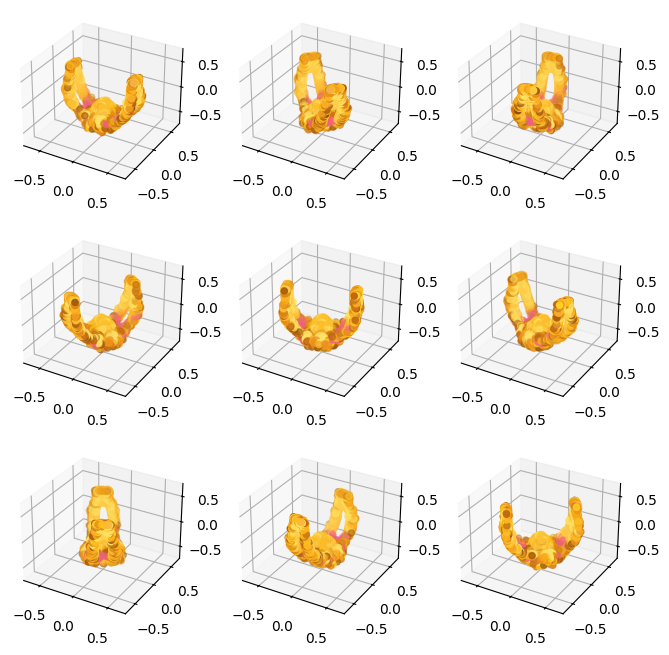

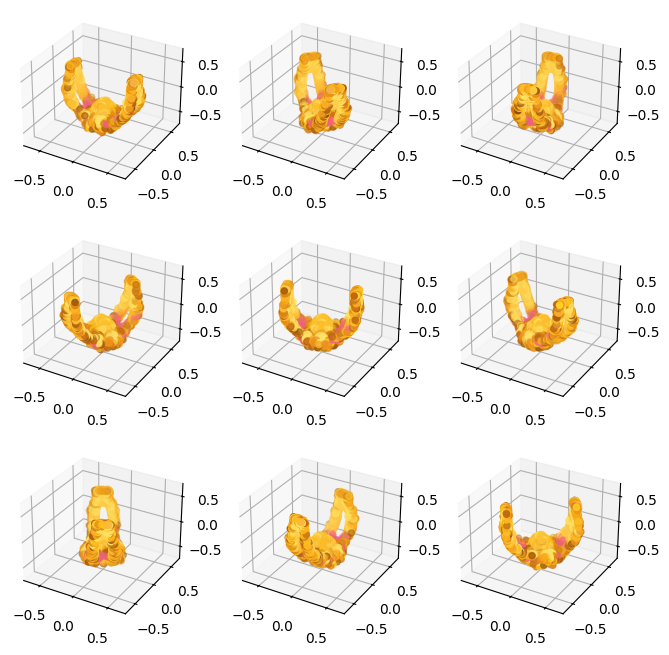

In [34]:
plot_point_cloud(pc, grid_size=3, fixed_bounds=((-0.75, -0.75, -0.75), (0.75, 0.75, 0.75)))

In [35]:
import trimesh
import numpy as np
print("Converting to mesh...")
points = pc.coords
point_cloud_mesh = trimesh.points.PointCloud(points)
mesh = point_cloud_mesh.convex_hull
mesh_filename = 'output_mesh.obj'
mesh.export(mesh_filename)
print("Mesh exported successfully!")

Converting to mesh...
Mesh exported successfully!


In [36]:
from google.colab import files
files.download(mesh_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>